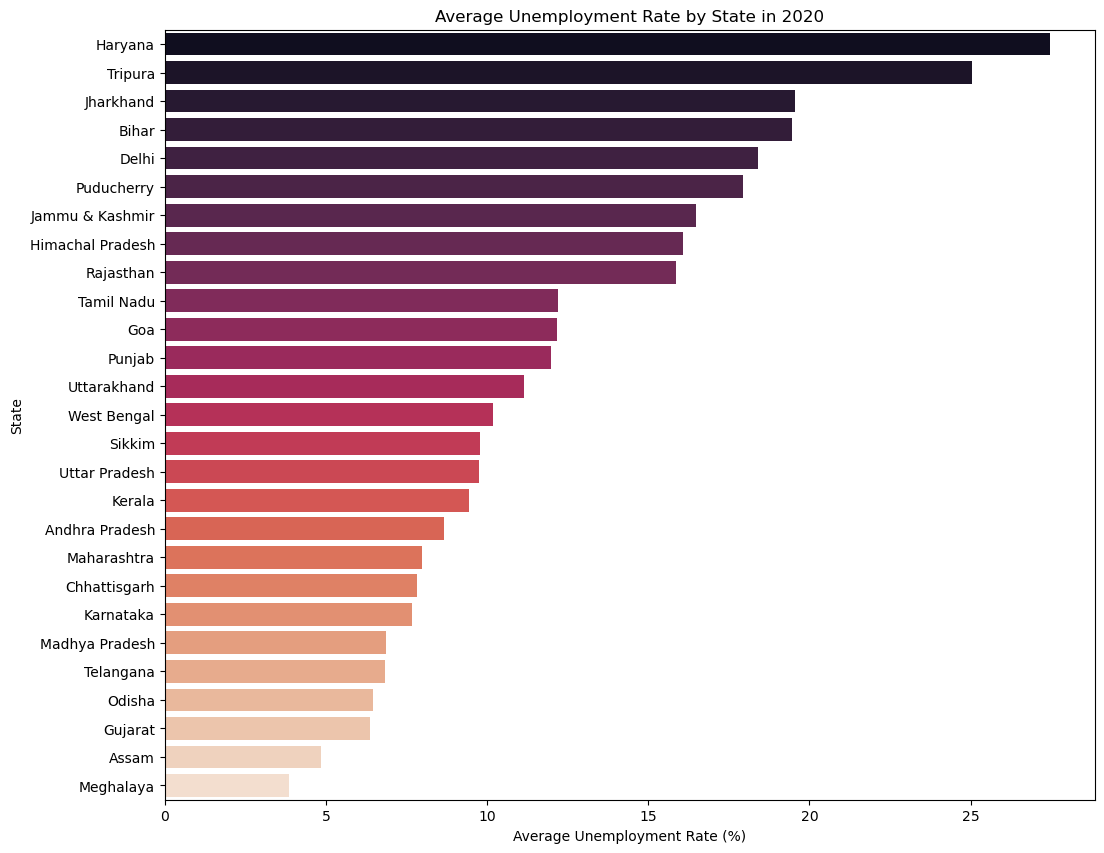

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Load Data
url = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv'
df = pd.read_csv(url)

# 2. Clean Column Names
df.columns = df.columns.str.strip()

# 3. Handle Missing Values
df = df.dropna()

# 4. Rename Columns correctly
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Region': 'State', 
    'Region.1': 'Area'
})

# 5. Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 6. Filter data for 2020
df_2020 = df[df['Date'].dt.year == 2020]

# 7. Create the State-wise Analysis
state_stats = df_2020.groupby('State')['Unemployment_Rate'].mean().reset_index().sort_values(by='Unemployment_Rate', ascending=False)

# 8. Plotting (The Fixed Version)
plt.figure(figsize=(12, 10))
sns.barplot(
    data=state_stats, 
    x='Unemployment_Rate', 
    y='State', 
    hue='State', 
    palette='rocket', 
    legend=False
)

plt.title('Average Unemployment Rate by State in 2020')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.show()
